# Macroeconomic Scenario Engine

## Objective

The objective of this notebook is to explore historical macroeconomic conditions and identify economic cycles relevant to credit risk modelling under IFRS 9.

Historical macroeconomic data between 2005 and 2026 are analysed to:

- assess data quality and completeness
- understand long-term economic trends
- identify recessionary and stress periods
- evaluate relationships between macroeconomic variables
- provide an empirical basis for constructing forward-looking macroeconomic scenarios

The outputs from this notebook will be used in subsequent notebooks to adjust borrower Probability of Default (PD) estimates under different macroeconomic scenarios.

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [24]:
df_macro = pd.read_csv("../outputs/Master_Macroeconomic_Data_Quarterly.csv")

df_macro.head()

,observation_date,Year,Quarter,Real_GDP,Unemployment_Rate,Federal_Funds_Rate,CPI,House_Price_Index,Disposable_Personal_Income,GDP_Growth,CPI_Rate,HPI_Growth,Income_Growth
0,2005-03-31,2005,1,15844.727,5.300000,2.470000,192.366667,163.482333,11241.433333,NaN,NaN,NaN,NaN
1,2005-06-30,2005,2,15922.782,5.100000,2.943333,193.666667,169.349333,11344.133333,0.492624,0.675793,3.588767,0.913585
2,2005-09-30,2005,3,16047.587,4.966667,3.460000,196.600000,174.580667,11385.866667,0.783814,1.514630,3.089078,0.367885
3,2005-12-31,2005,4,16136.734,4.966667,3.980000,198.433333,179.541000,11488.000000,0.555517,0.932519,2.841284,0.897019
4,2006-03-31,2006,1,16353.835,4.733333,4.456667,199.466667,183.324000,11700.700000,1.345384,0.520746,2.107040,1.851497


In [25]:
df_macro["observation_date"] = pd.to_datetime(df_macro["observation_date"])

df_macro = df_macro.sort_values("observation_date")

In [26]:
print(df_macro.shape)

(85, 13)


In [27]:
missing = (
    df_macro
    .isnull()
    .sum()
    .to_frame("Missing Values")
)

missing["Percentage"] = (
    missing["Missing Values"]
    / len(df_macro)
    *100
)

missing

,Missing Values,Percentage
observation_date,0,0.000000
Year,0,0.000000
Quarter,0,0.000000
Real_GDP,0,0.000000
Unemployment_Rate,0,0.000000
Federal_Funds_Rate,0,0.000000
CPI,0,0.000000
House_Price_Index,0,0.000000
Disposable_Personal_Income,0,0.000000
GDP_Growth,1,1.176471


In [28]:
print(df_macro.duplicated().sum())

0


In [29]:
df_macro.dtypes

observation_date              datetime64[ns]
Year                                   int64
Quarter                                int64
Real_GDP                             float64
Unemployment_Rate                    float64
Federal_Funds_Rate                   float64
CPI                                  float64
House_Price_Index                    float64
Disposable_Personal_Income           float64
GDP_Growth                           float64
CPI_Rate                             float64
HPI_Growth                           float64
Income_Growth                        float64
dtype: object

In [30]:
df_macro.describe().T

,count,mean,min,25%,50%,75%,max,std
observation_date,85,2015-09-30 06:46:35.294117632,2005-03-31 00:00:00,2010-06-30 00:00:00,2015-09-30 00:00:00,2020-12-31 00:00:00,2026-03-31 00:00:00,NaN
Year,85.0,2015.129412,2005.0,2010.0,2015.0,2020.0,2026.0,6.171726
Quarter,85.0,2.482353,1.0,1.0,2.0,3.0,4.0,1.12981
Real_GDP,85.0,19200.303506,15844.727,16915.191,18857.418,20985.448,24180.419,2500.279679
Unemployment_Rate,85.0,5.727255,3.533333,4.166667,4.933333,6.933333,13.0,2.102349
Federal_Funds_Rate,85.0,1.828039,0.06,0.123333,0.77,3.653333,5.33,1.974449
CPI,85.0,247.0534,192.366667,217.934333,237.689333,261.091667,326.588,36.829496
House_Price_Index,85.0,205.509369,137.003333,161.950333,182.818333,233.132333,332.055,61.957542
Disposable_Personal_Income,85.0,14379.194902,11241.433333,12510.566667,13937.9,16353.833333,18470.433333,2154.078368
GDP_Growth,84.0,0.513674,-7.876784,0.265415,0.615584,0.853408,7.762279,1.358241


In [31]:
variables = [
    "GDP_Growth",
    "Unemployment_Rate",
    "Federal_Funds_Rate",
    "CPI_Rate",
    "HPI_Growth",
    "Income_Growth"
]

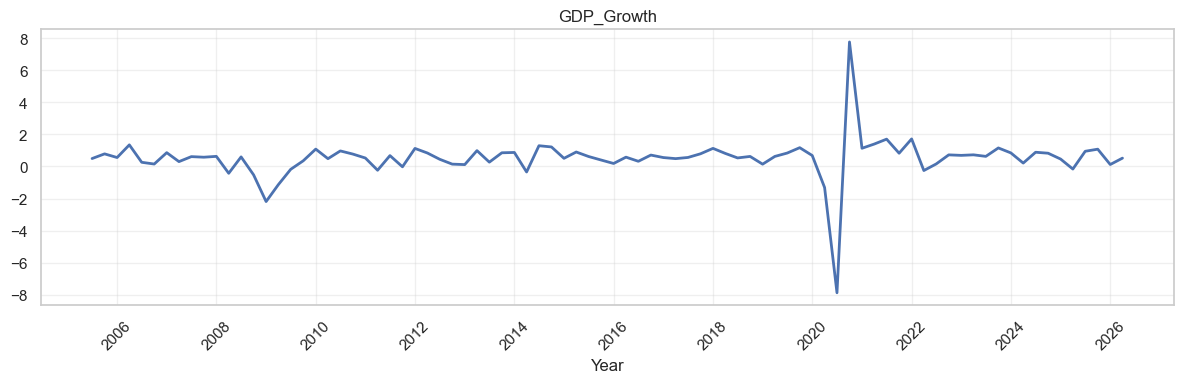

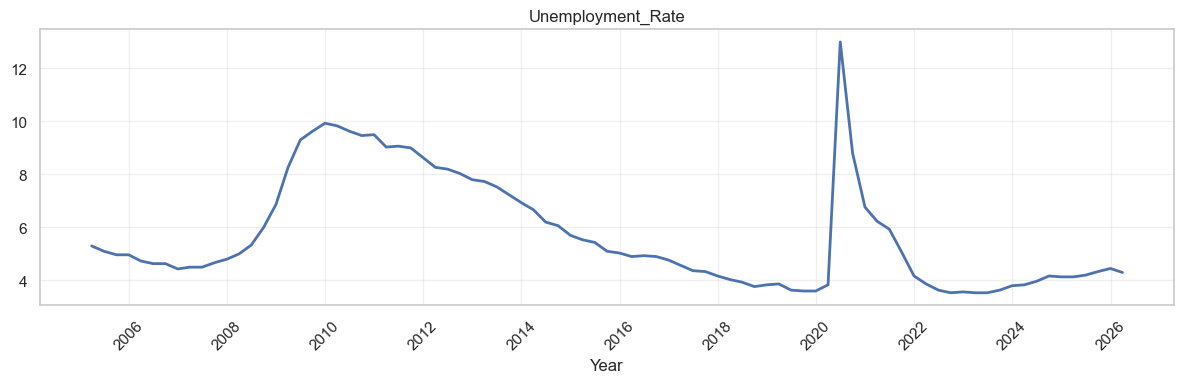

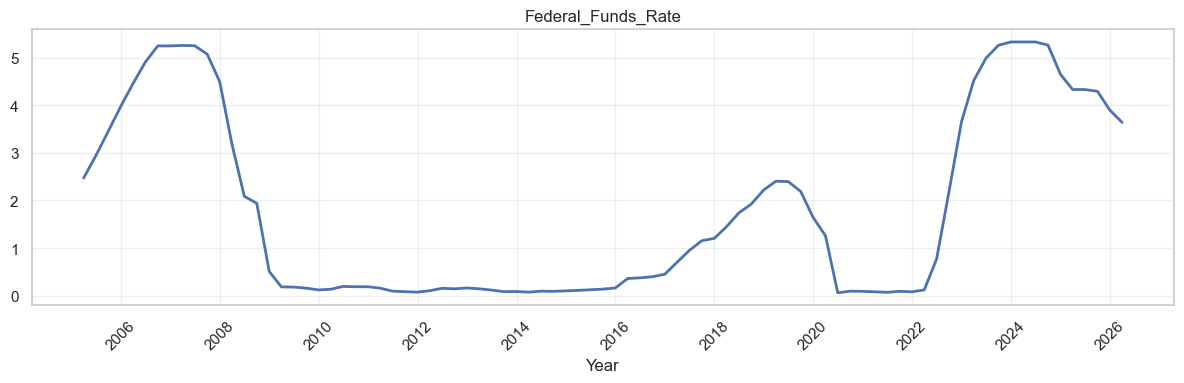

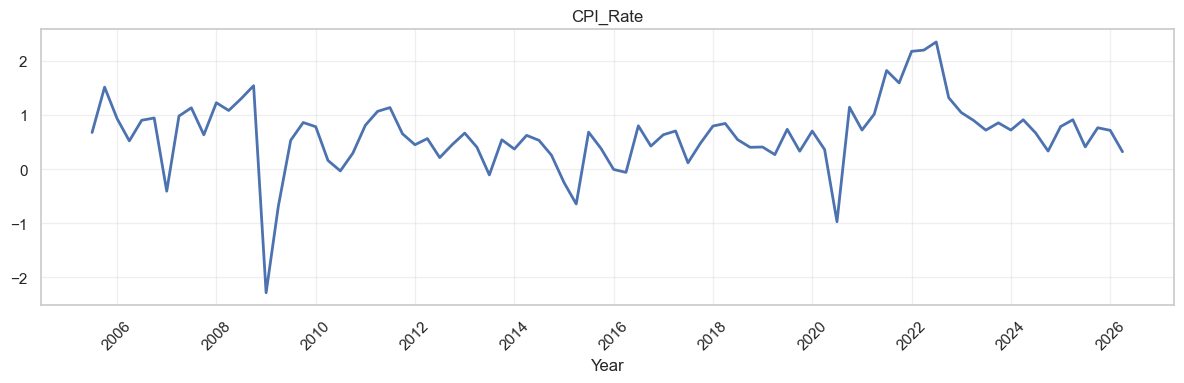

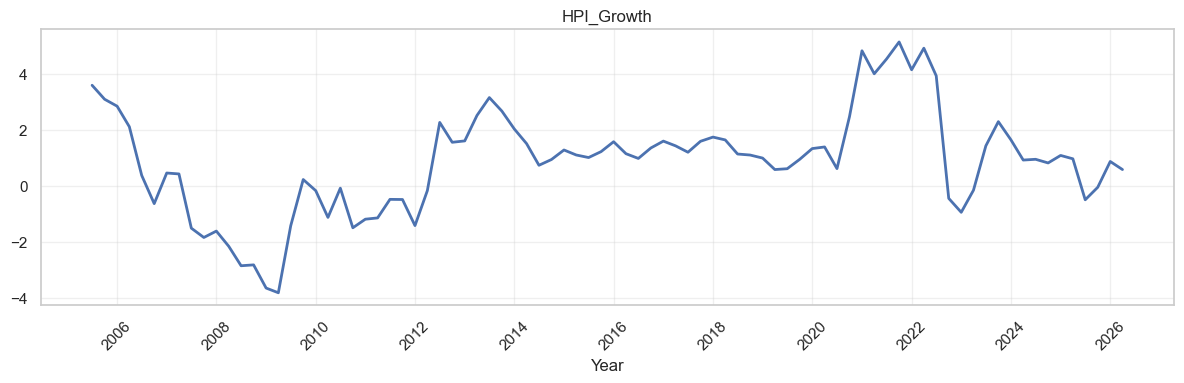

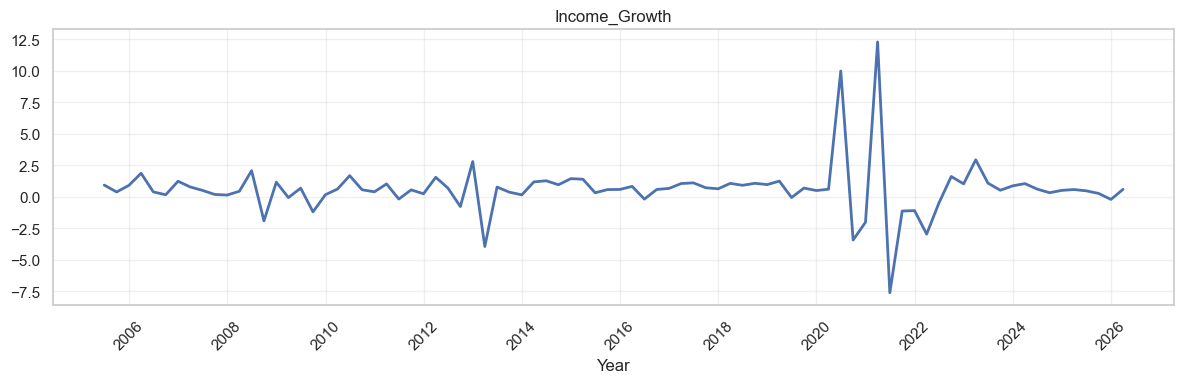

In [32]:
import matplotlib.dates as mdates

df_macro["observation_date"] = pd.to_datetime(df_macro["observation_date"])

for col in variables:

    plt.figure(figsize=(12, 4))

    plt.plot(
        df_macro["observation_date"],
        df_macro[col],
        linewidth=2
    )

    plt.title(col)
    plt.xlabel("Year")

    ax = plt.gca()

    ax.xaxis.set_major_locator(mdates.YearLocator(2))

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.xticks(rotation=45)

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

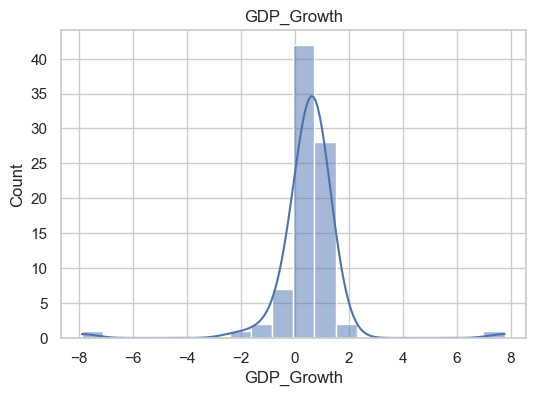

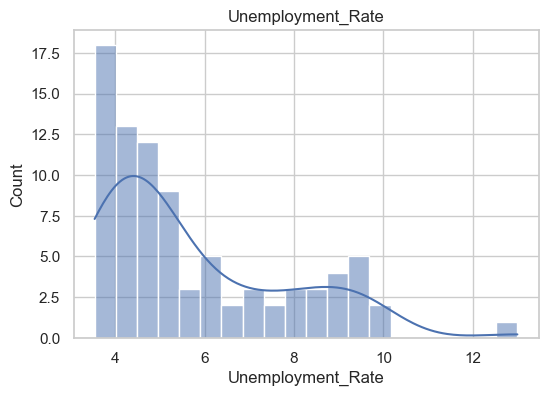

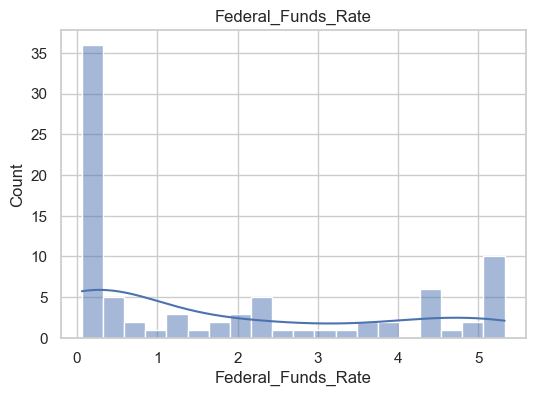

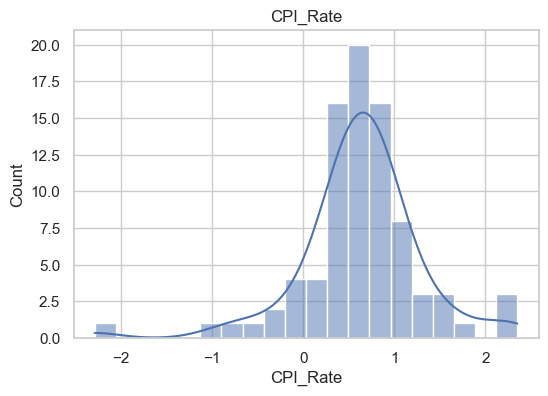

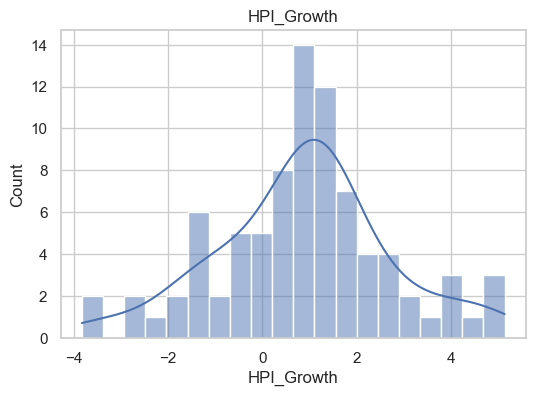

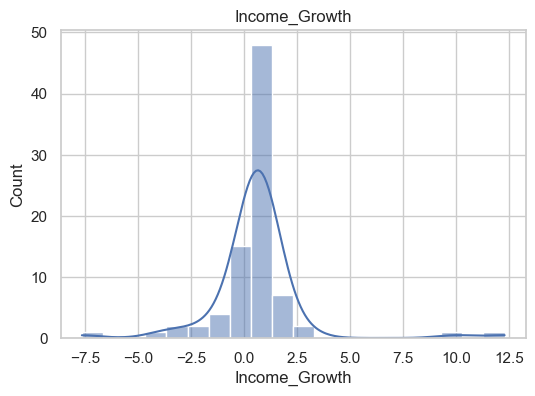

In [33]:
for col in variables:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df_macro[col],
        bins=20,
        kde=True
    )

    plt.title(col)

    plt.show()

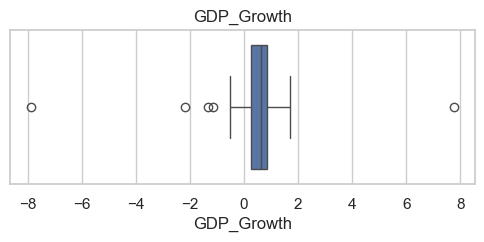

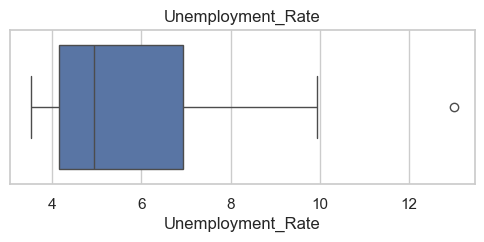

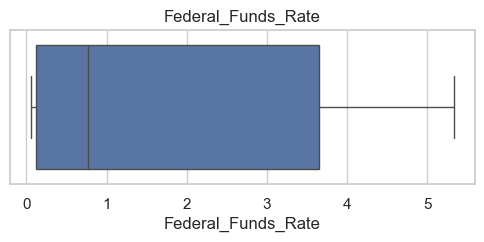

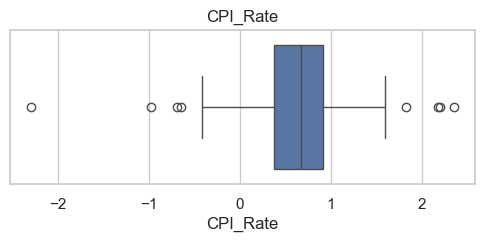

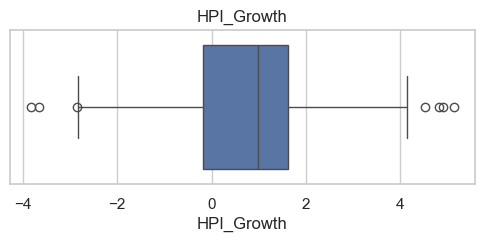

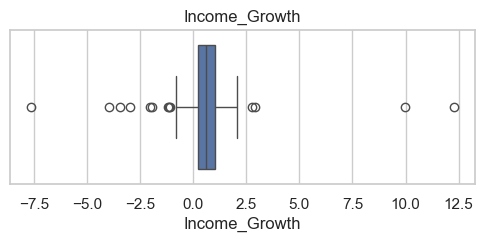

In [34]:
for col in variables:

    plt.figure(figsize=(6,2))

    sns.boxplot(
        x=df_macro[col]
    )

    plt.title(col)

    plt.show()

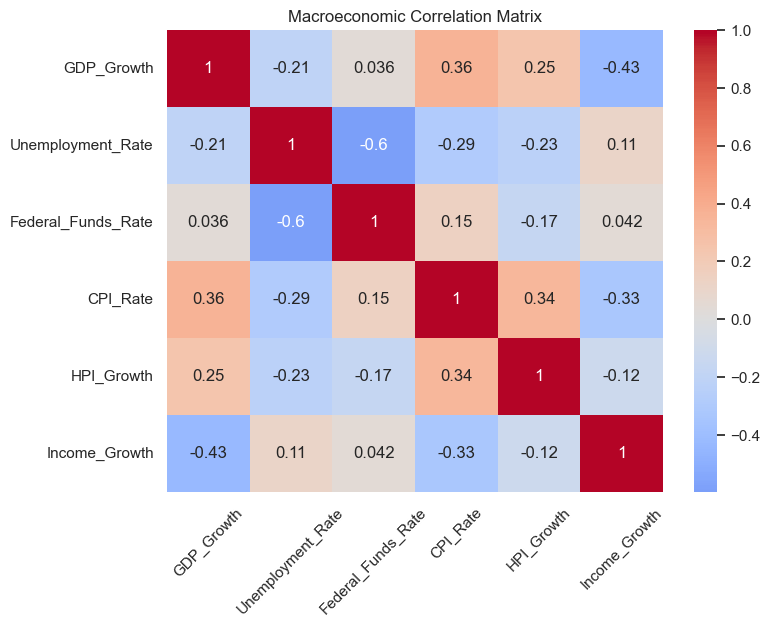

In [35]:
corr = (
    df_macro[variables]
    .corr()
)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Macroeconomic Correlation Matrix")

plt.xticks(rotation=45)

plt.show()

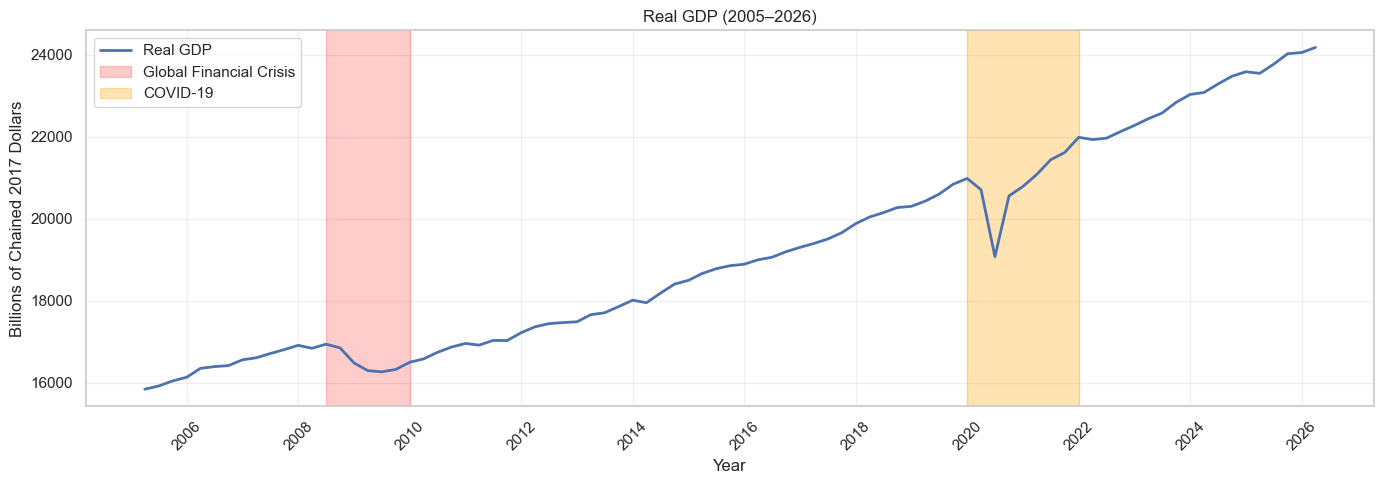

In [36]:
df_macro["observation_date"] = pd.to_datetime(df_macro["observation_date"])

plt.figure(figsize=(14,5))

plt.plot(
    df_macro["observation_date"],
    df_macro["Real_GDP"],
    linewidth=2,
    label="Real GDP"
)

plt.axvspan(
    pd.Timestamp("2008-07-01"),
    pd.Timestamp("2009-12-31"),
    color="red",
    alpha=0.2,
    label="Global Financial Crisis"
)

plt.axvspan(
    pd.Timestamp("2020-01-01"),
    pd.Timestamp("2021-12-31"),
    color="orange",
    alpha=0.3,
    label="COVID-19"
)

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.YearLocator(2))

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)

plt.title("Real GDP (2005–2026)")
plt.xlabel("Year")
plt.ylabel("Billions of Chained 2017 Dollars")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

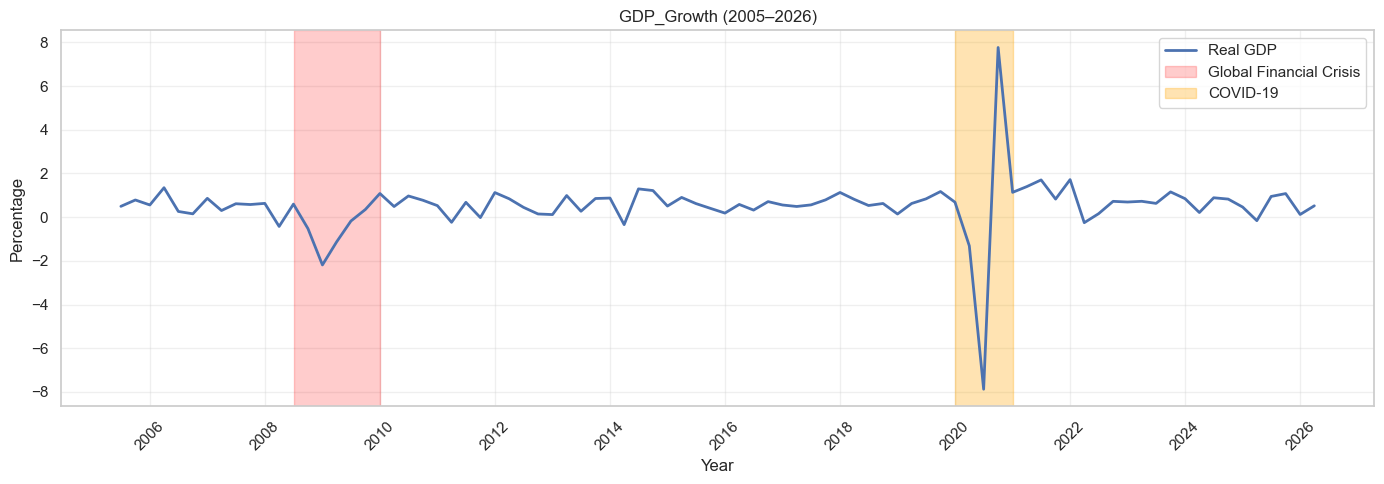

In [37]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ensure observation_date is datetime
df_macro["observation_date"] = pd.to_datetime(df_macro["observation_date"])

plt.figure(figsize=(14,5))

# GDP line
plt.plot(
    df_macro["observation_date"],
    df_macro["GDP_Growth"],
    linewidth=2,
    label="Real GDP"
)

# Global Financial Crisis (2008Q3–2009Q4)
plt.axvspan(
    pd.Timestamp("2008-07-01"),
    pd.Timestamp("2009-12-31"),
    color="red",
    alpha=0.2,
    label="Global Financial Crisis"
)

# COVID-19 (2020Q1–2020Q3)
plt.axvspan(
    pd.Timestamp("2020-01-01"),
    pd.Timestamp("2020-12-31"),
    color="orange",
    alpha=0.3,
    label="COVID-19"
)

# Format x-axis
ax = plt.gca()

# Show one tick every 2 years
ax.xaxis.set_major_locator(mdates.YearLocator(2))

# Display only the year
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)

plt.title("GDP_Growth (2005–2026)")
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [38]:
rolling_vol = (
    df_macro[variables]
    .rolling(4)
    .std()
)

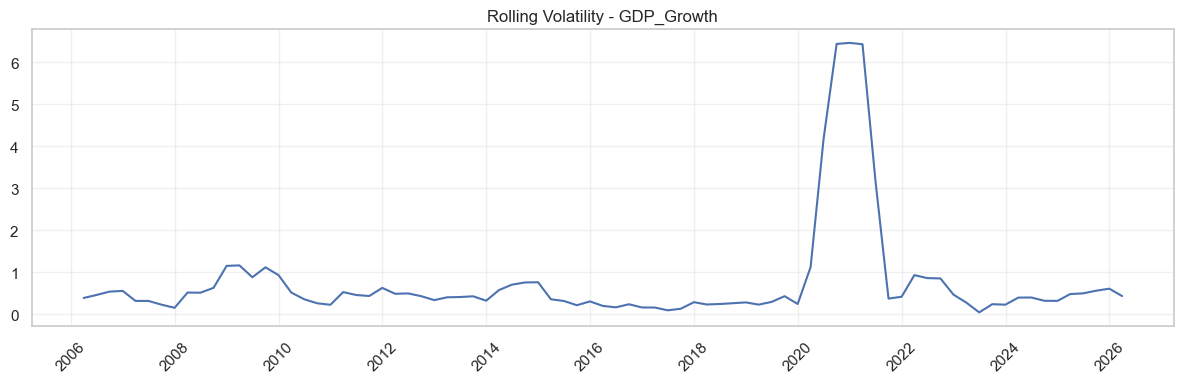

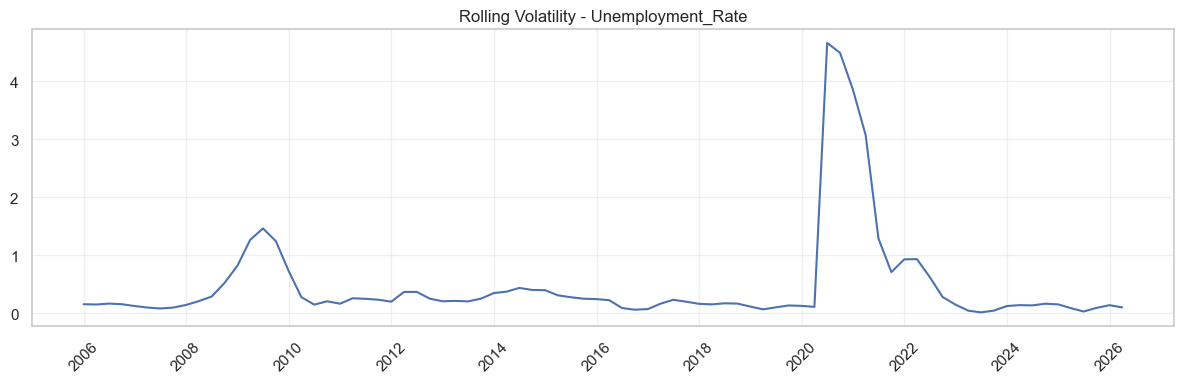

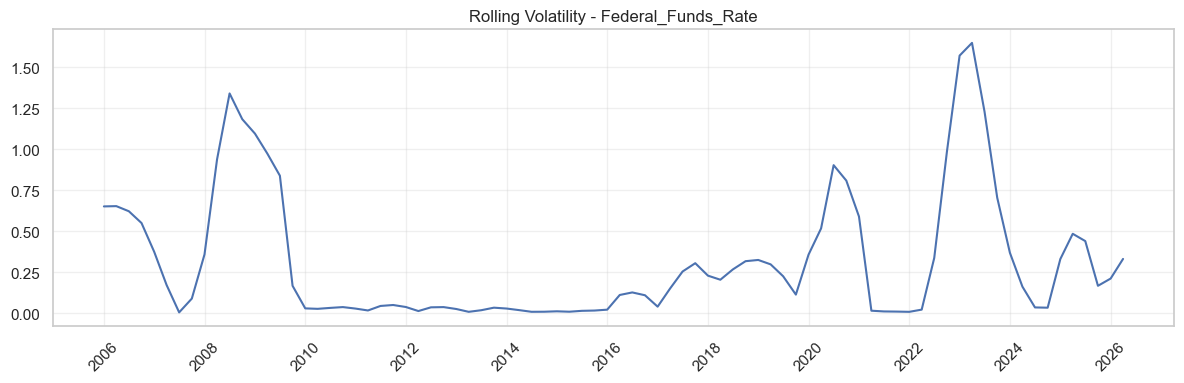

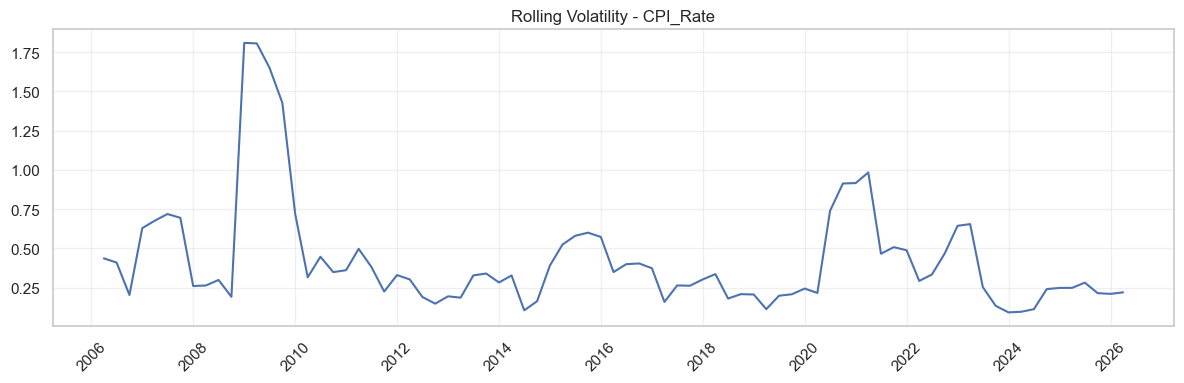

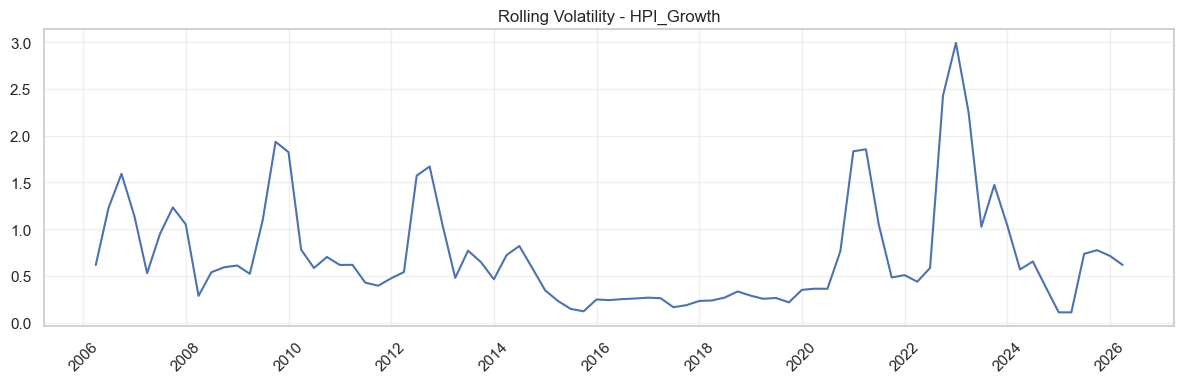

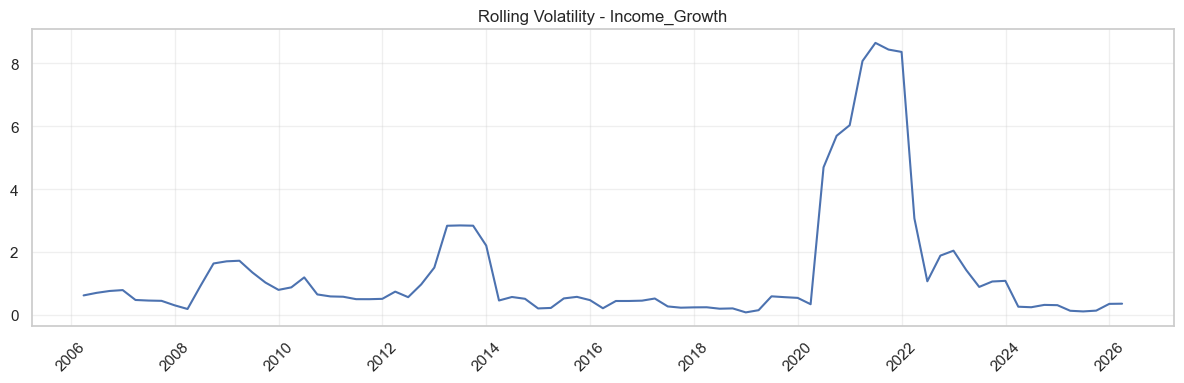

In [39]:
for col in variables:

    plt.figure(figsize=(12,4))

    plt.plot(
        df_macro["observation_date"],
        rolling_vol[col]
    )

    plt.title(f"Rolling Volatility - {col}")

    ax = plt.gca()

    ax.xaxis.set_major_locator(mdates.YearLocator(2))

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    plt.xticks(rotation=45)

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [40]:
stress_periods = {
    "GFC": ("2008-07-01", "2009-12-31"),
    "COVID": ("2020-01-01", "2020-12-31")
}

In [41]:
stress_summary = []

for name, (start, end) in stress_periods.items():

    temp = df_macro[
        (df_macro["observation_date"] >= pd.Timestamp(start)) &
        (df_macro["observation_date"] <= pd.Timestamp(end))
    ]

    summary = pd.Series({
        "GDP_Growth": temp["GDP_Growth"].quantile(0.10),
        "Unemployment_Rate": temp["Unemployment_Rate"].quantile(0.90),
        "Federal_Funds_Rate": temp["Federal_Funds_Rate"].quantile(0.10),
        "CPI_Rate": temp["CPI_Rate"].quantile(0.90),
        "HPI_Growth": temp["HPI_Growth"].quantile(0.10),
        "Income_Growth": temp["Income_Growth"].quantile(0.10)

    })

    summary["Scenario"] = name

    stress_summary.append(summary)

stress_summary = (
    pd.DataFrame(stress_summary)
    .set_index("Scenario")
)

stress_summary

,GDP_Growth,Unemployment_Rate,Federal_Funds_Rate,CPI_Rate,HPI_Growth,Income_Growth
Scenario,,,,,,
GFC,-1.661950,9.783333,0.138333,1.201137,-3.74156,-1.567608
COVID,-5.908646,11.740000,0.069000,1.016585,0.84216,-3.021443


In [42]:
scenario_table = pd.DataFrame(index=variables)

scenario_table["Baseline"] = (
    df_macro[variables]
    .tail(8)
    .mean()
)

scenario_table["Downside"] = (
    stress_summary.loc["GFC"]
)

scenario_table["Severe"] = (
    stress_summary.loc["COVID"]
)

scenario_table

,Baseline,Downside,Severe
GDP_Growth,0.583571,-1.661950,-5.908646
Unemployment_Rate,4.210417,9.783333,11.740000
Federal_Funds_Rate,4.466667,0.138333,0.069000
CPI_Rate,0.613294,1.201137,1.016585
HPI_Growth,0.585053,-3.741560,0.842160
Income_Growth,0.377772,-1.567608,-3.021443
